In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Path to the data folder
data_folder = os.path.join(os.path.dirname("*"), "data")

# Get all image files from the data folder
image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tiff")
image_files = [f for f in os.listdir(data_folder) if f.lower().endswith(image_extensions)]
image_files

['form117.png',
 'form103.png',
 'form81.png',
 'form95.png',
 'form42.png',
 'form56.png',
 'form473.png',
 'form315.png',
 'form301.png',
 'form467.png',
 'form329.png',
 'form498.png',
 'form507.png',
 'form261.png',
 'form275.png',
 'form249.png',
 'form248.png',
 'form274.png',
 'form506.png',
 'form260.png',
 'form499.png',
 'form328.png',
 'form300.png',
 'form466.png',
 'form472.png',
 'form314.png',
 'form57.png',
 'form43.png',
 'form94.png',
 'form80.png',
 'form102.png',
 'form116.png',
 'form100.png',
 'form114.png',
 'form96.png',
 'form82.png',
 'form128.png',
 'form69.png',
 'form55.png',
 'form41.png',
 'form464.png',
 'form302.png',
 'form316.png',
 'form470.png',
 'form458.png',
 'form276.png',
 'form262.png',
 'form504.png',
 'form289.png',
 'form288.png',
 'form263.png',
 'form505.png',
 'form277.png',
 'form459.png',
 'form317.png',
 'form471.png',
 'form465.png',
 'form303.png',
 'form40.png',
 'form54.png',
 'form68.png',
 'form83.png',
 'form129.png',
 'form97.

In [2]:
len(image_files)

506

In [14]:
first_image = image_files[10]
first_image

'form329.png'

Loaded: form329.png | Size: (1700, 2200) | Mode: 1


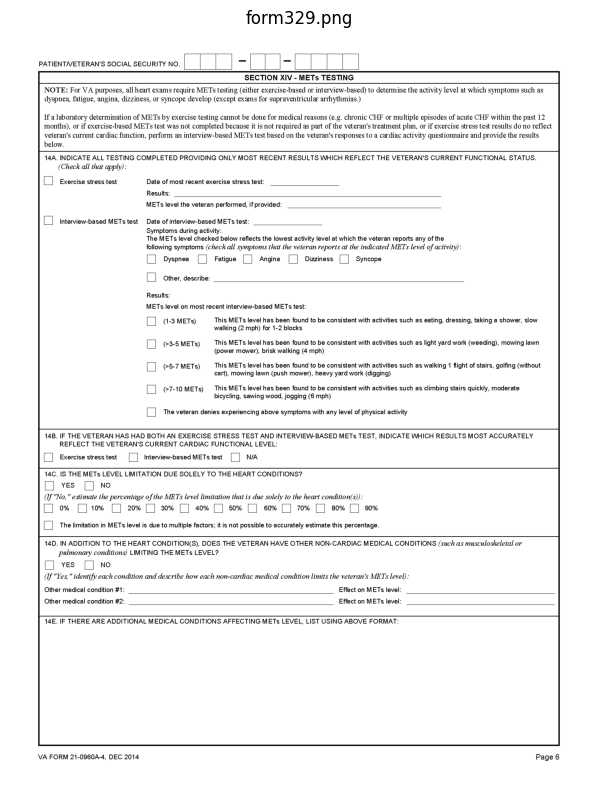

In [15]:
image_path = os.path.join(data_folder, first_image)
img = Image.open(image_path)

print(f"Loaded: {first_image} | Size: {img.size} | Mode: {img.mode}")

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(first_image)
plt.axis("off")
plt.tight_layout()
plt.show()

Loading: data/form329.png
Image size: 1700 x 2200 px
Total rectangles detected: 454

=== Detection Summary ===
  Text / input fields : 3
  Checkboxes / radios : 71

Text fields (x, y, w, h):
  [1] x=839, y=65, w=188, h=47
  [2] x=708, y=65, w=88, h=47
  [3] x=514, y=65, w=140, h=47

Checkboxes (x, y, w, h):
  [1] x=221, y=1556, w=26, h=26
  [2] x=221, y=1556, w=26, h=26
  [3] x=104, y=1556, w=26, h=26
  [4] x=104, y=1556, w=26, h=26
  [5] x=101, y=1439, w=26, h=26
  [6] x=101, y=1439, w=26, h=26
  [7] x=1001, y=1389, w=26, h=26
  [8] x=1001, y=1389, w=26, h=26
  [9] x=901, y=1389, w=26, h=26
  [10] x=901, y=1389, w=26, h=26
  ... and 61 more


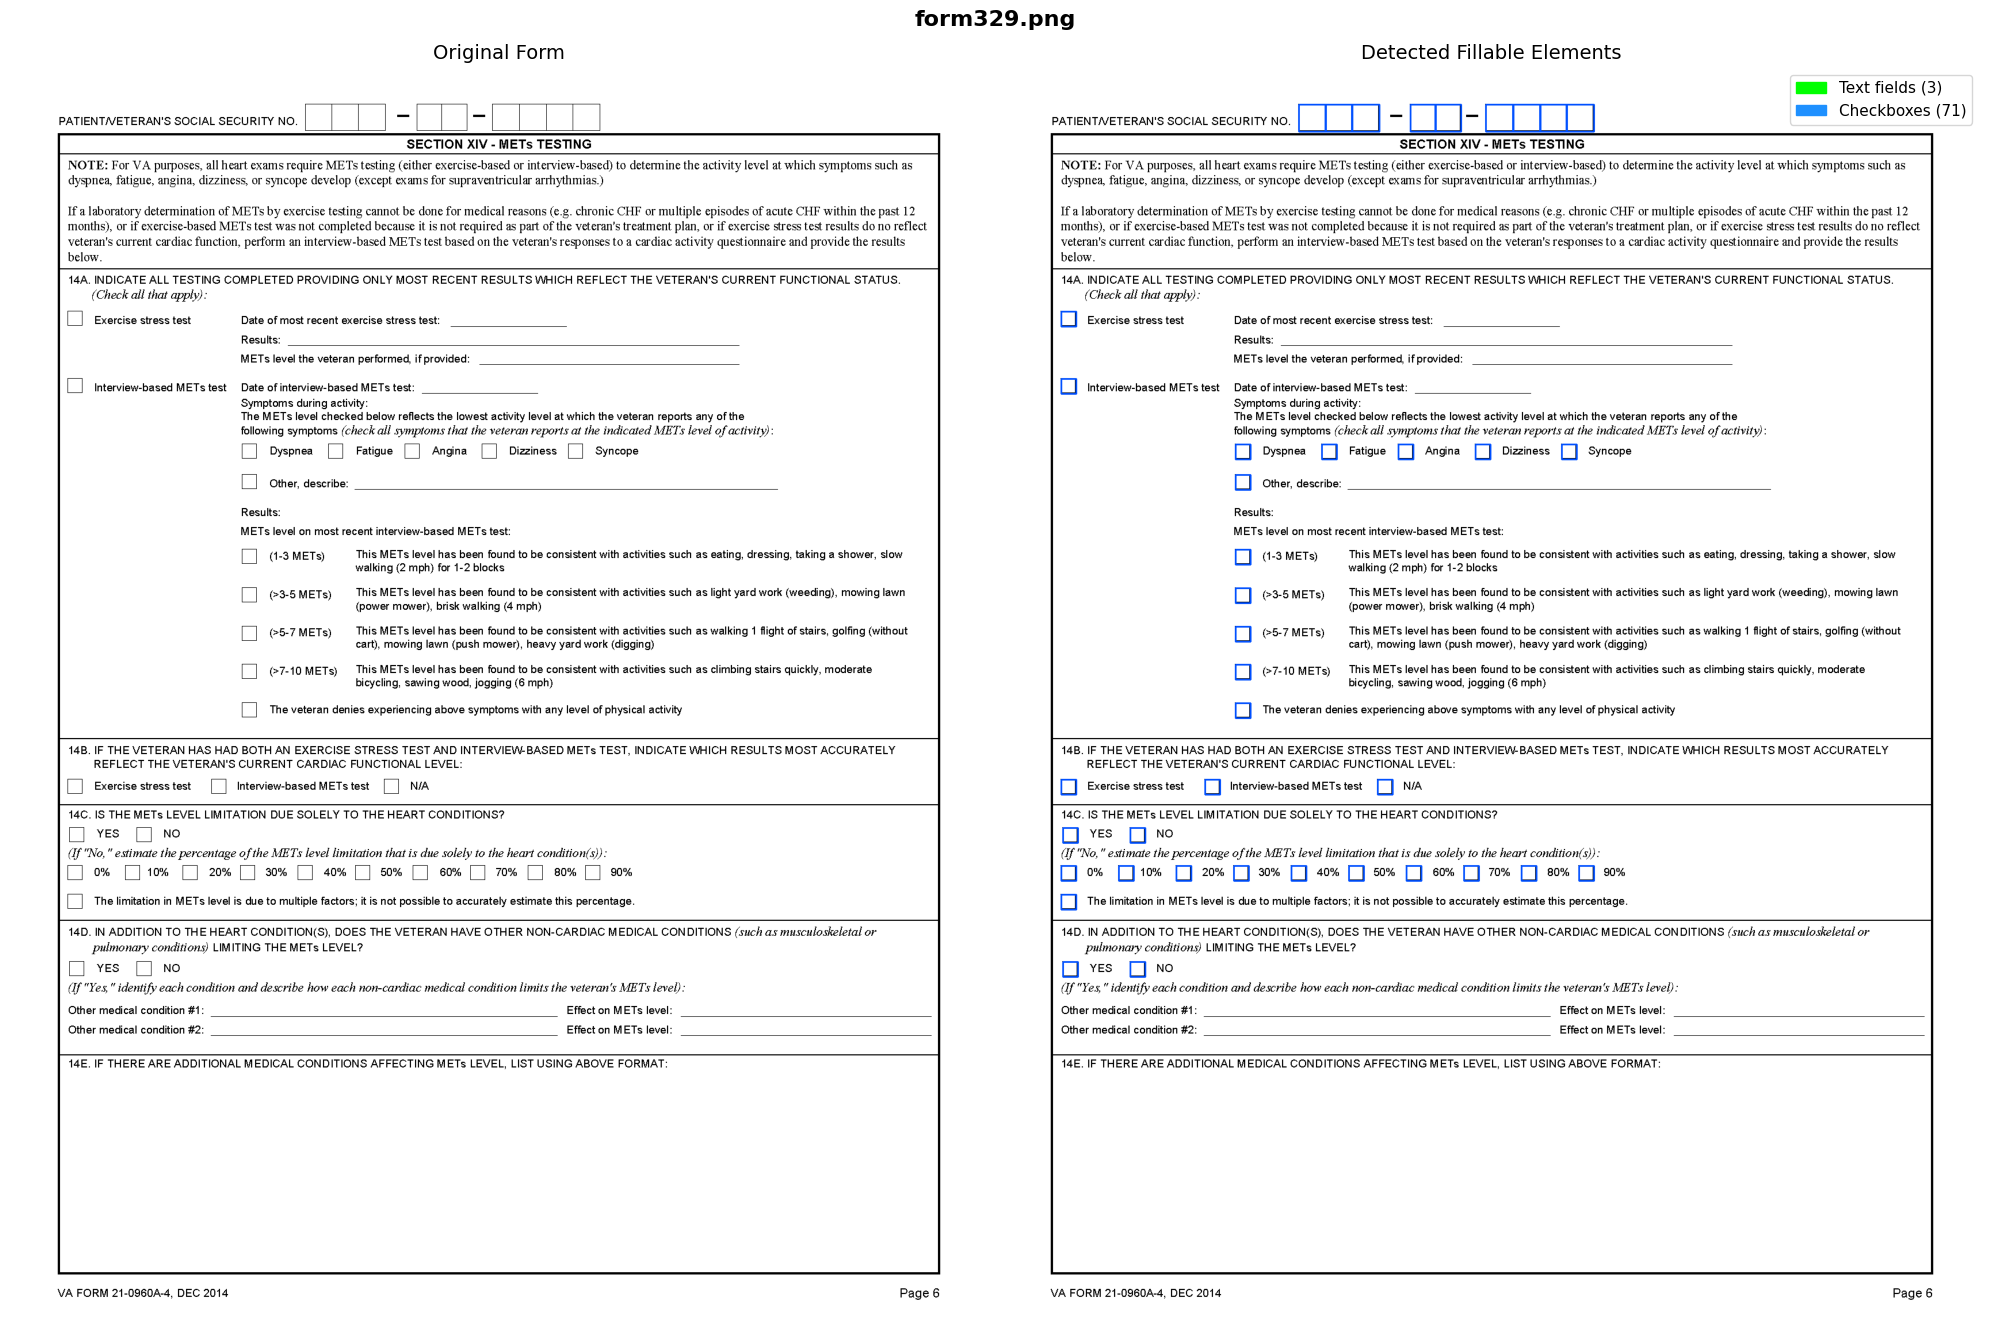


Annotated image saved → detected_fields.png


In [20]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_FOLDER = os.path.join(os.path.dirname("*"), "data")
IMAGE_NAME  = "form329.png"          # ← change to any form image
IMAGE_PATH  = os.path.join(DATA_FOLDER, IMAGE_NAME)

# Tuning knobs (tweak if detection is off)
MIN_TEXT_FIELD_W   = 60    # min width  of a text-input box (px)
MIN_TEXT_FIELD_H   = 10    # min height of a text-input box (px)
MAX_TEXT_FIELD_W   = 1400  # ignore page-width rectangles
MAX_TEXT_FIELD_H   = 80    # taller than this → not a text field
CHECKBOX_MIN       = 10    # min side length for checkbox / radio
CHECKBOX_MAX       = 50    # max side length for checkbox / radio
SQUARE_TOLERANCE   = 0.30  # how close to square (0 = perfect square)

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_image(path):
    """Load with OpenCV; handle 1-bit (binary) PNGs via Pillow."""
    img_pil = Image.open(path).convert("L")          # to 8-bit grayscale
    img = np.array(img_pil)
    return img

def preprocess(gray):
    """Binarise and clean up noise."""
    # Otsu threshold → clean binary
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Light morphological closing to join broken rectangle edges
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary

def detect_rectangles(binary):
    """Find all rectangular contours and return their bounding boxes."""
    contours, _ = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    rects = []
    for cnt in contours:
        peri   = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:                         # quadrilateral
            x, y, w, h = cv2.boundingRect(approx)
            rects.append((x, y, w, h))
    return rects

def classify_elements(rects, img_w, img_h):
    """Split rectangles into text fields, checkboxes, and unknowns."""
    text_fields = []
    checkboxes  = []
    unknowns    = []

    for (x, y, w, h) in rects:
        # Skip full-page bounding boxes
        if w > img_w * 0.95 or h > img_h * 0.95:
            continue

        aspect  = w / h if h > 0 else 0
        squareness = abs(1 - (w / h)) if h > 0 else 99

        # ── Checkbox / radio button ─────────────────
        if (CHECKBOX_MIN <= w <= CHECKBOX_MAX and
            CHECKBOX_MIN <= h <= CHECKBOX_MAX and
            squareness <= SQUARE_TOLERANCE):
            checkboxes.append((x, y, w, h))

        # ── Text input field ────────────────────────
        elif (MIN_TEXT_FIELD_W <= w <= MAX_TEXT_FIELD_W and
              MIN_TEXT_FIELD_H <= h <= MAX_TEXT_FIELD_H and
              aspect >= 1.5):                         # wider than tall
            text_fields.append((x, y, w, h))

    return text_fields, checkboxes

def draw_results(gray, text_fields, checkboxes):
    """Overlay coloured bounding boxes and return an annotated RGB image."""
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for (x, y, w, h) in text_fields:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 180, 0), 2)    # green

    for (x, y, w, h) in checkboxes:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 80, 0), 2)   # blue

    return vis

def print_summary(text_fields, checkboxes):
    print("\n=== Detection Summary ===")
    print(f"  Text / input fields : {len(text_fields)}")
    print(f"  Checkboxes / radios : {len(checkboxes)}")
    print("=========================\n")

    if text_fields:
        print("Text fields (x, y, w, h):")
        for i, r in enumerate(text_fields[:10]):   # show first 10
            print(f"  [{i+1}] x={r[0]}, y={r[1]}, w={r[2]}, h={r[3]}")
        if len(text_fields) > 10:
            print(f"  ... and {len(text_fields)-10} more")

    if checkboxes:
        print("\nCheckboxes (x, y, w, h):")
        for i, r in enumerate(checkboxes[:10]):
            print(f"  [{i+1}] x={r[0]}, y={r[1]}, w={r[2]}, h={r[3]}")
        if len(checkboxes) > 10:
            print(f"  ... and {len(checkboxes)-10} more")

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def main():
    print(f"Loading: {IMAGE_PATH}")
    gray   = load_image(IMAGE_PATH)
    h_img, w_img = gray.shape

    print(f"Image size: {w_img} x {h_img} px")

    binary = preprocess(gray)
    rects  = detect_rectangles(binary)

    print(f"Total rectangles detected: {len(rects)}")

    text_fields, checkboxes = classify_elements(rects, w_img, h_img)
    print_summary(text_fields, checkboxes)

    # ── Visualise ───────────────────────────────
    vis = draw_results(gray, text_fields, checkboxes)

    legend = [
        mpatches.Patch(color="lime",       label=f"Text fields ({len(text_fields)})"),
        mpatches.Patch(color="dodgerblue", label=f"Checkboxes ({len(checkboxes)})"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(20, 14))

    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Original Form", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Detected Fillable Elements", fontsize=14)
    axes[1].legend(handles=legend, loc="upper right", fontsize=11)
    axes[1].axis("off")

    plt.suptitle(IMAGE_NAME, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── Optional: save annotated image ──────────
    out_path = os.path.join(os.path.dirname("*"), "detected_fields.png")
    cv2.imwrite(out_path, vis)
    print(f"\nAnnotated image saved → {out_path}")


if __name__ == "__main__":
    main()

Loading: data/form329.png
Image size: 1700 x 2200 px

=== Detection Summary ===
  Checkboxes / radios : 71
  Input lines         : 12



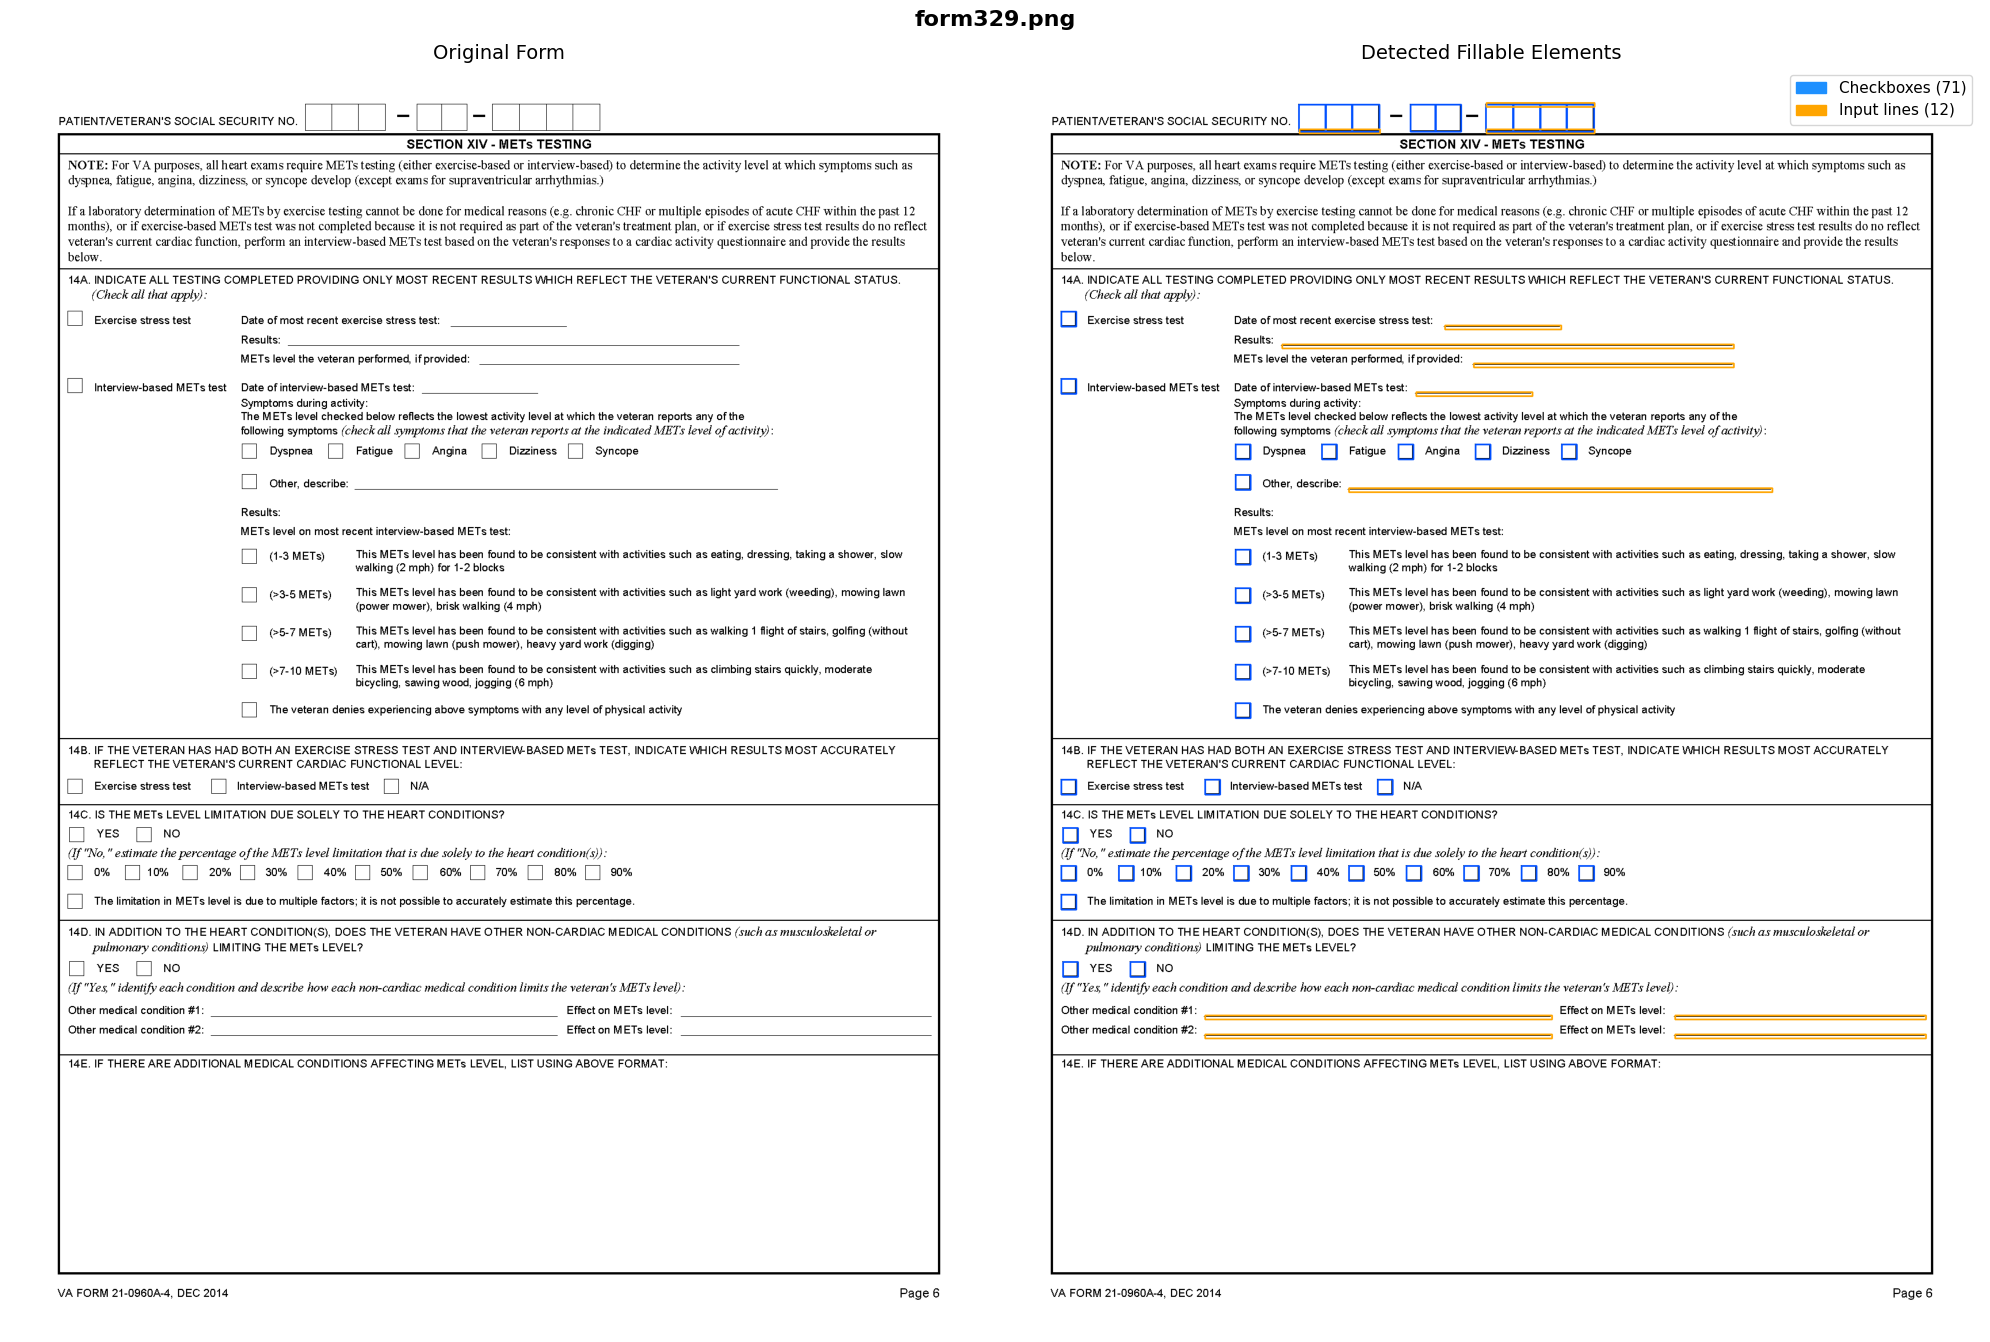

Annotated image saved → detected_fields.png


In [29]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_FOLDER = os.path.join(os.path.dirname("*"), "data")
IMAGE_NAME  = "form329.png"          # ← change to any form image
IMAGE_PATH  = os.path.join(DATA_FOLDER, IMAGE_NAME)

# Checkbox detection
CHECKBOX_MIN      = 10    # min side length (px)
CHECKBOX_MAX      = 50    # max side length (px)
SQUARE_TOLERANCE  = 0.30  # 0 = perfect square

# Input line detection
LINE_MIN_W        = 100   # min width (px)
LINE_MAX_H        = 4     # max thickness (px) — must look like a line, not a box
LABEL_SEARCH_PX   = 300   # how far left to look for a label
LABEL_PIXEL_RATIO = 0.01  # min dark pixel ratio to confirm label exists

# ─────────────────────────────────────────────
# IMAGE LOADING & PREPROCESSING
# ─────────────────────────────────────────────

def load_image(path):
    """Load any PNG (including 1-bit) as 8-bit grayscale."""
    img_pil = Image.open(path).convert("L")
    return np.array(img_pil)

def preprocess(gray):
    """Otsu binarisation + light closing to join broken edges."""
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    return cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# ─────────────────────────────────────────────
# CHECKBOX DETECTION
# ─────────────────────────────────────────────

def detect_checkboxes(binary, img_w, img_h):
    """Find small near-square rectangles = checkboxes / radio buttons."""
    contours, _ = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    checkboxes = []
    for cnt in contours:
        peri   = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) != 4:
            continue
        x, y, w, h = cv2.boundingRect(approx)
        # Skip full-page shapes
        if w > img_w * 0.95 or h > img_h * 0.95:
            continue
        squareness = abs(1 - (w / h)) if h > 0 else 99
        if (CHECKBOX_MIN <= w <= CHECKBOX_MAX and
                CHECKBOX_MIN <= h <= CHECKBOX_MAX and
                squareness <= SQUARE_TOLERANCE):
            checkboxes.append((x, y, w, h))
    return checkboxes

# ─────────────────────────────────────────────
# INPUT LINE DETECTION
# ─────────────────────────────────────────────

def detect_input_lines(binary, checkboxes):
    """
    Find horizontal lines that:
      1. Are wide and thin (not a box).
      2. Have text/label pixels to their left.
      3. Do NOT share the same coordinates as any checkbox.
    """
    # Step 1: isolate horizontal strokes
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    h_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(h_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Must be wide and thin
        if w < LINE_MIN_W or h > LINE_MAX_H:
            continue

        # Step 2: check for label text to the left
        lx1 = max(0, x - LABEL_SEARCH_PX)
        lx2 = max(0, x - 5)
        ly1 = max(0, y - 10)
        ly2 = min(binary.shape[0], y + h + 10)

        if lx2 <= lx1:
            continue

        region = binary[ly1:ly2, lx1:lx2]
        if region.size == 0:
            continue
        if np.count_nonzero(region) / region.size <= LABEL_PIXEL_RATIO:
            continue

        # Step 3: reject if this line is inside or near a checkbox
        VICINITY = 20  # px — how close is "too close"
        near_checkbox = any(
            x >= cx - VICINITY and x + w <= cx + cw + VICINITY and
            y >= cy - VICINITY and y + h <= cy + ch + VICINITY
            for (cx, cy, cw, ch) in checkboxes
        )
        if near_checkbox:
            continue

        lines.append((x, y, w, h))

    return lines

# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def draw_results(gray, checkboxes, input_lines):
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for (x, y, w, h) in checkboxes:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 80, 0), 2)       # blue

    for (x, y, w, h) in input_lines:
        cv2.rectangle(vis, (x, y-3), (x+w, y+h+3), (0, 165, 255), 2)  # orange

    return vis

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def main():
    print(f"Loading: {IMAGE_PATH}")
    gray = load_image(IMAGE_PATH)
    h_img, w_img = gray.shape
    print(f"Image size: {w_img} x {h_img} px")

    binary = preprocess(gray)

    checkboxes  = detect_checkboxes(binary, w_img, h_img)
    input_lines = detect_input_lines(binary, checkboxes)

    print(f"\n=== Detection Summary ===")
    print(f"  Checkboxes / radios : {len(checkboxes)}")
    print(f"  Input lines         : {len(input_lines)}")
    print(f"=========================\n")

    vis = draw_results(gray, checkboxes, input_lines)

    legend = [
        mpatches.Patch(color="dodgerblue", label=f"Checkboxes ({len(checkboxes)})"),
        mpatches.Patch(color="orange",     label=f"Input lines ({len(input_lines)})"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(20, 14))

    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Original Form", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Detected Fillable Elements", fontsize=14)
    axes[1].legend(handles=legend, loc="upper right", fontsize=11)
    axes[1].axis("off")

    plt.suptitle(IMAGE_NAME, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

    out_path = os.path.join(os.path.dirname("*"), "detected_fields.png")
    cv2.imwrite(out_path, vis)
    print(f"Annotated image saved → {out_path}")


if __name__ == "__main__":
    main()